# **Car Price Prediction - Linear & Ridge Regression**

# **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# **1. Load dataset**

In [4]:
# source
# https://www.kaggle.com/code/sumedh1507/audi-car-price-prediction/input

file_path = "cars_dataset.csv"
data = pd.read_csv(file_path)
data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [242]:
print("\nInfo")
data.info()


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  object 
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  object 
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  object 
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  object 
dtypes: float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [243]:
print("\nMissing values per column:")
data.isnull().sum()


Missing values per column:


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

### **Consider to drop rows with missing price or zero price**

In [244]:
data = data[data['price'] > 0].copy()

# **2. EDA for Numerical variables**

In [245]:
print("\nSummary statistics (numeric columns)")
data.describe()


Summary statistics (numeric columns)


,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000



Numeric columns: ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']


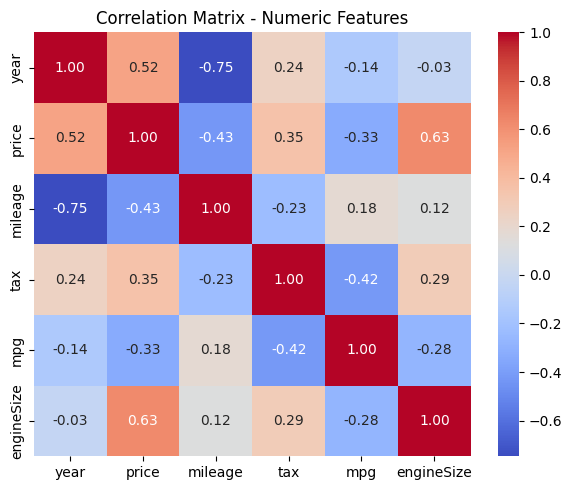

In [246]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("\nNumeric columns:", numeric_cols)

corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

# **3. Numeric-only model for clear feature importance**

In [247]:
# Numeric features for a simple linear model
numeric_features_for_importance = [col for col in numeric_cols if col != 'price']

X_num = data[numeric_features_for_importance]
y = data['price']

X_num_train, X_num_test, y_num_train, y_num_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

# Linear Regression model
num_model = LinearRegression()
num_model.fit(X_num_train, y_num_train)
y_num_pred = num_model.predict(X_num_test)

# Metrics
mse_num = mean_squared_error(y_num_test, y_num_pred)
rmse_num = np.sqrt(mse_num)
r2_num = r2_score(y_num_test, y_num_pred)

print("\nNumeric-only Linear Regression")
print(f"RMSE: {rmse_num:.2f}")
print(f"R²:   {r2_num:.4f}")


Numeric-only Linear Regression
RMSE: 5067.32
R²:   0.7103


In [248]:
# Numeric feature importance
num_coeffs = pd.DataFrame(
    num_model.coef_,
    index=numeric_features_for_importance,
    columns=['Coefficient']
)
num_coeffs['Abs_Coefficient'] = num_coeffs['Coefficient'].abs()
num_coeffs_sorted = num_coeffs.sort_values('Abs_Coefficient', ascending=False)

print("\nNumeric feature importance (coefficients)")
num_coeffs_sorted


Numeric feature importance (coefficients)


,Coefficient,Abs_Coefficient
engineSize,10819.940068,10819.940068
year,1583.366698,1583.366698
mpg,-32.573331,32.573331
tax,-0.824430,0.824430
mileage,-0.101106,0.101106


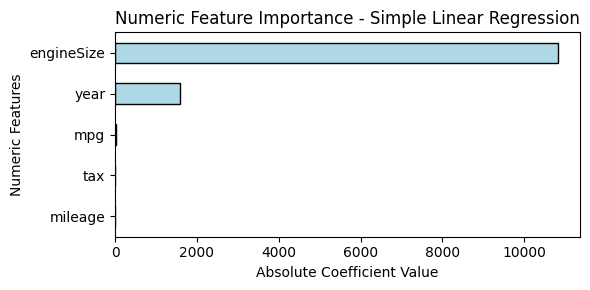

In [249]:
plt.figure(figsize=(6, 3))
num_coeffs_sorted['Abs_Coefficient'].plot(
    kind='barh',
    color='lightblue',
    edgecolor='black'
)
plt.title('Numeric Feature Importance - Simple Linear Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Numeric Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **4. Linear model with dummies**

In [250]:
# One-hot encode all categorical variables
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(columns=['price'])
y = data_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nShapes (original full model)")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression with dummies")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")


Shapes (original full model)
X_train: (57948, 163)
X_test : (14487, 163)

Linear Regression with dummies
RMSE: 3246.87
R²:   0.8811


## **4.1 Residuals**

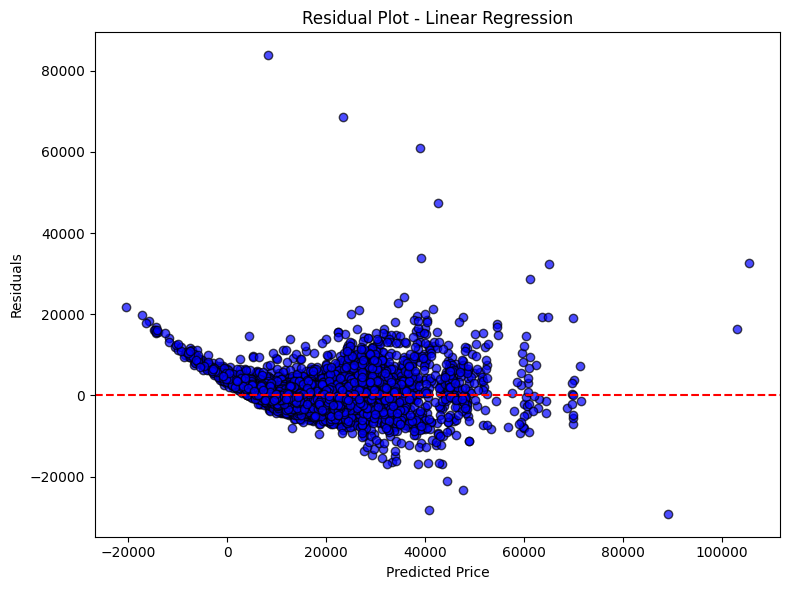

In [251]:
# Residual plot with all variables
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='blue', edgecolor='k', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot - Linear Regression')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

In [252]:
# 10-fold Cross Validation
cv_scores = cross_val_score(
    LinearRegression(), X, y, cv=10,
    scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(np.abs(cv_scores))
print("\n10-fold Cross Validation for Linear Regression model")
print("RMSE per fold:", cv_rmse)
print(f"Mean RMSE: {cv_rmse.mean():.2f}")
print(f"Std RMSE:  {cv_rmse.std():.2f}")


10-fold Cross Validation for Linear Regression model
RMSE per fold: [4739.02209077 4658.22605679 4565.04910828 1830.21007883 2042.2941636
 2929.97557221 5122.2205421  6692.65586433 3484.96075242 4162.49487651]
Mean RMSE: 4022.71
Std RMSE:  1406.43


# **5. IMPROVED MODEL: selected features + poly + Ridge**

## **5.1 Select only key numeric features that are interpretable and relevant for price prediction**

In [253]:
# Interpretable numeric features
numeric_base = []
for col in ['year', 'mileage', 'mpg', 'engineSize', 'tax']:
    if col in data.columns:
        numeric_base.append(col)

# Key categorical features for one-hot encoding
categorical_base = []
for col in ['model', 'transmission', 'fuelType', 'brand', 'Make', 'make']:
    if col in data.columns:
        categorical_base.append(col)

print("\nNumeric base features:", numeric_base)
print("Categorical base features:", categorical_base)


Numeric base features: ['year', 'mileage', 'mpg', 'engineSize', 'tax']
Categorical base features: ['model', 'transmission', 'fuelType', 'Make']


## **5.2 Clean subset**

In [254]:
cols_for_model = numeric_base + categorical_base + ['price']
data_small = data[cols_for_model].dropna().copy()

## **5.3 Domain feature engineering**

In [255]:
# domain feature: car_age
# age 0 = newest, age 5 = 5 years old
if 'year' in data_small.columns:
    data_small['car_age'] = data_small['year'].max() + 1 - data_small['year']

# one-hot encode only selected categoricals
data_small_enc = pd.get_dummies(
    data_small,
    columns=categorical_base,
    drop_first=True
)

## **5.4 Final feature matrix (X) and target (y) for Ridge regression**

In [256]:
X2 = data_small_enc.drop(columns=['price'])
y2 = data_small_enc['price']

# Standard 80/20 train-test split with fixed random_state for reproducibility
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print("\nShapes (improved base model)")
print("X2_train:", X2_train.shape)
print("X2_test :", X2_test.shape)


Shapes (improved base model)
X2_train: (57948, 164)
X2_test : (14487, 164)


## **5.5 Polynomial features**

### **5.5.1 Numerical features**

In [257]:

num_improved = [c for c in X2.columns if c in numeric_base or c == 'car_age']
X2_train_num = X2_train[num_improved]
X2_test_num = X2_test[num_improved]

# Quadratic polynomial features (degree=2) on numerics only
poly = PolynomialFeatures(degree=2, include_bias=False)
X2_train_poly = poly.fit_transform(X2_train_num)
X2_test_poly = poly.transform(X2_test_num)

# Meaningful polynomial feature names (e.g., 'mileage^2', 'car_age mileage')
poly_feature_names = poly.get_feature_names_out(num_improved)
X2_train_poly_df = pd.DataFrame(X2_train_poly, index=X2_train.index, columns=poly_feature_names)
X2_test_poly_df = pd.DataFrame(X2_test_poly, index=X2_test.index, columns=poly_feature_names)

### **5.5.2 Categorical features**

In [258]:
# Identify categorical dummy columns
categorical_dummy_cols = [c for c in X2.columns if c not in num_improved]

# Feature Matrix with numerics (polynomial) + original categoricals
X2_train_final = pd.concat([X2_train_poly_df, X2_train[categorical_dummy_cols]], axis=1)
X2_test_final = pd.concat([X2_test_poly_df, X2_test[categorical_dummy_cols]], axis=1)

print("\nShapes after polynomial features (improved)")
print("X2_train_final:", X2_train_final.shape)
print("X2_test_final :", X2_test_final.shape)


Shapes after polynomial features (improved)
X2_train_final: (57948, 185)
X2_test_final : (14487, 185)


## **5.6 Standard Scalation**

In [259]:
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train_final)
X2_test_scaled = scaler.transform(X2_test_final)

## **5.7 Ridge model application**

In [260]:
# Ridge model
ridge = Ridge(alpha=20.0, random_state=42)
ridge.fit(X2_train_scaled, y2_train)
y2_pred = ridge.predict(X2_test_scaled)

# Metrics
mse2 = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y2_test, y2_pred)

print("\nImproved Ridge Model")
print(f"RMSE: {rmse2:.2f}")
print(f"R²:   {r22:.4f}")


Improved Ridge Model
RMSE: 2683.61
R²:   0.9188


# **6. Comparison Original vs Improved**

In [261]:
print("\nComparison Original vs Improved")

comparison = {
    'Metric': ['RMSE', 'R²'],
    'Original': [f"{rmse:.2f}", f"{r2:.4f}"],
    'Improved': [f"{rmse2:.2f}", f"{r22:.4f}"]
}

comparison_dataframe = pd.DataFrame(comparison)
comparison_dataframe


Comparison Original vs Improved


,Metric,Original,Improved
0,RMSE,3246.87,2683.61
1,R²,0.8811,0.9188


## **Ridge feature importance**

In [262]:
ridge_coefs = pd.Series(ridge.coef_, index=X2_train_final.columns)
ridge_coefs_abs_sorted = ridge_coefs.abs().sort_values(ascending=False)

print("\nTop 15 coefficients (Ridge model)")
ridge_coefs_abs_sorted.head(15)


Top 15 coefficients (Ridge model)


mpg^2                 4880.509750
engineSize car_age    3416.203185
model_ i3             3308.876988
year engineSize       2197.891891
engineSize            2179.816617
engineSize^2          2168.721381
mileage engineSize    2089.314541
car_age^2             1835.747332
mpg engineSize        1711.709206
model_ X5             1163.937159
year mpg              1158.701596
mpg                   1152.669168
mileage car_age       1145.255089
engineSize tax        1115.612889
model_ Q7             1000.293514
dtype: float64

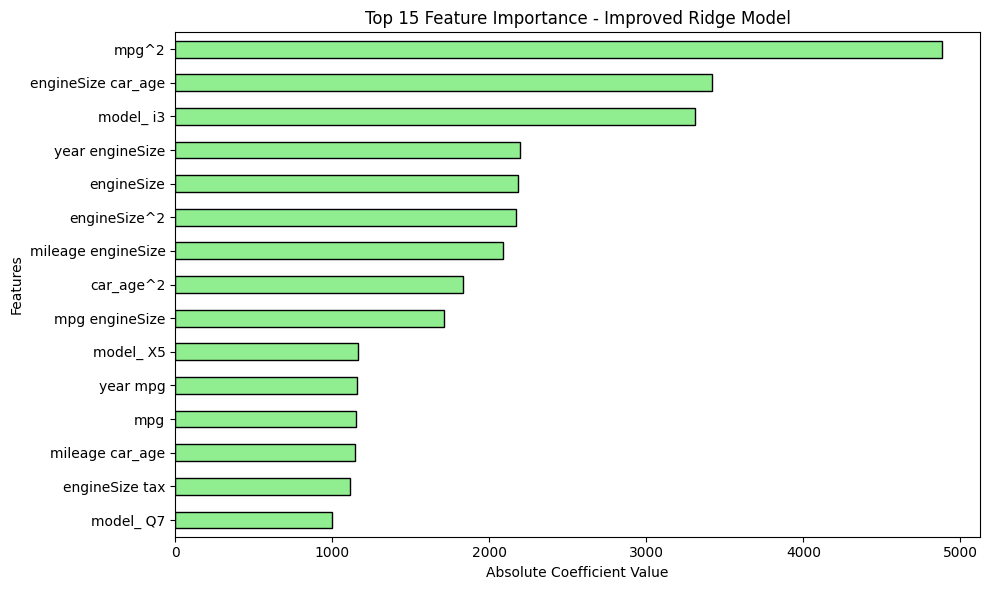

In [263]:
plt.figure(figsize=(10, 6))
ridge_coefs_abs_sorted.head(15).plot(
    kind='barh',
    color='lightgreen',
    edgecolor='black'
)
plt.title('Top 15 Feature Importance - Improved Ridge Model')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Residuals comparison**

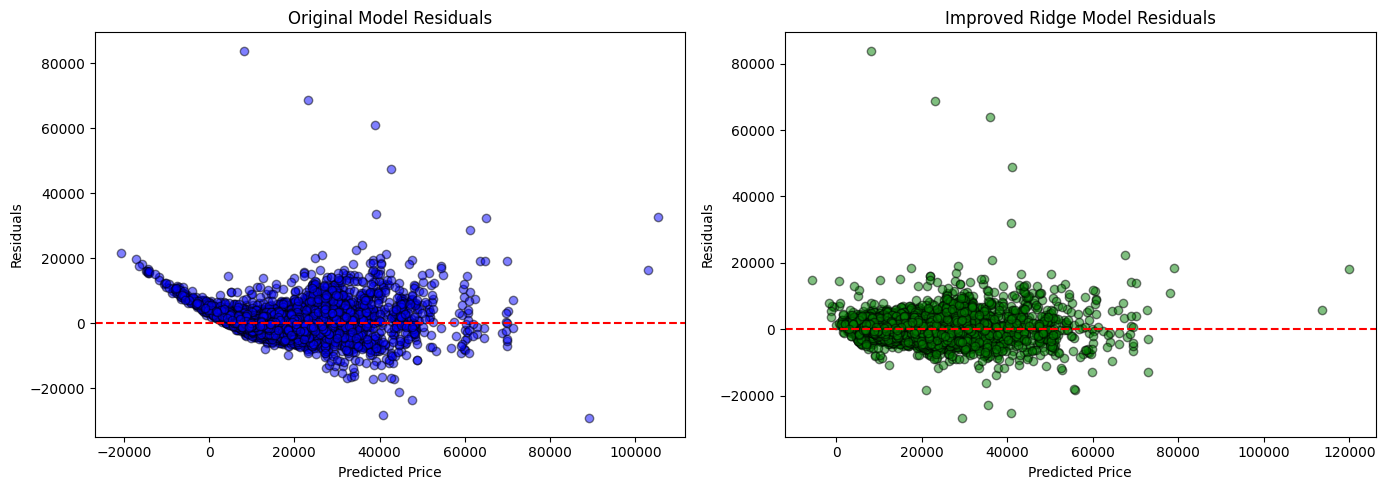

In [264]:
residuals2 = y2_test - y2_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color='blue', edgecolor='k')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Original Model Residuals')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')

axes[1].scatter(y2_pred, residuals2, alpha=0.5, color='green', edgecolor='k')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Improved Ridge Model Residuals')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()